Dataset loaded
  26 rows | 3 colleges | 5 branches | years 2022-2025

                   count   mean    min    max
branch_category                              
Computer-adjacent     18  98.76  94.68  99.96
Core/Traditional       8  96.99  92.56  99.30


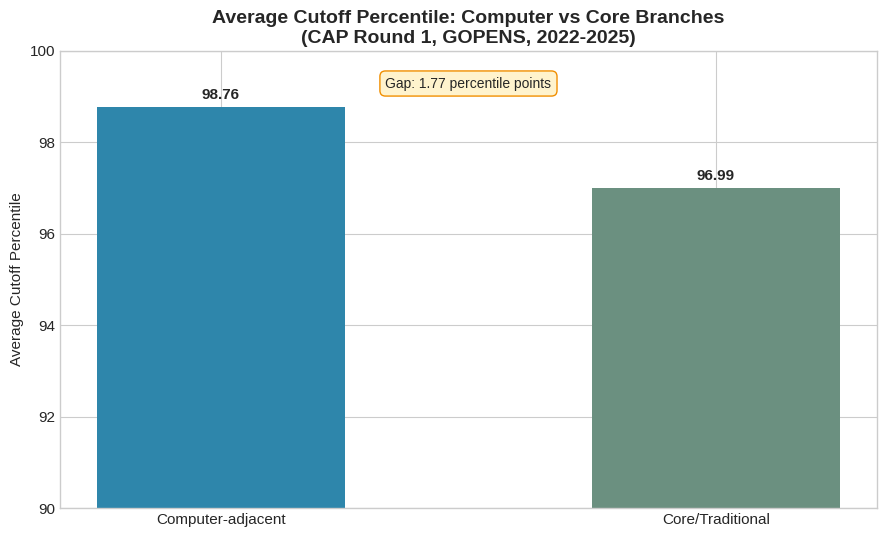

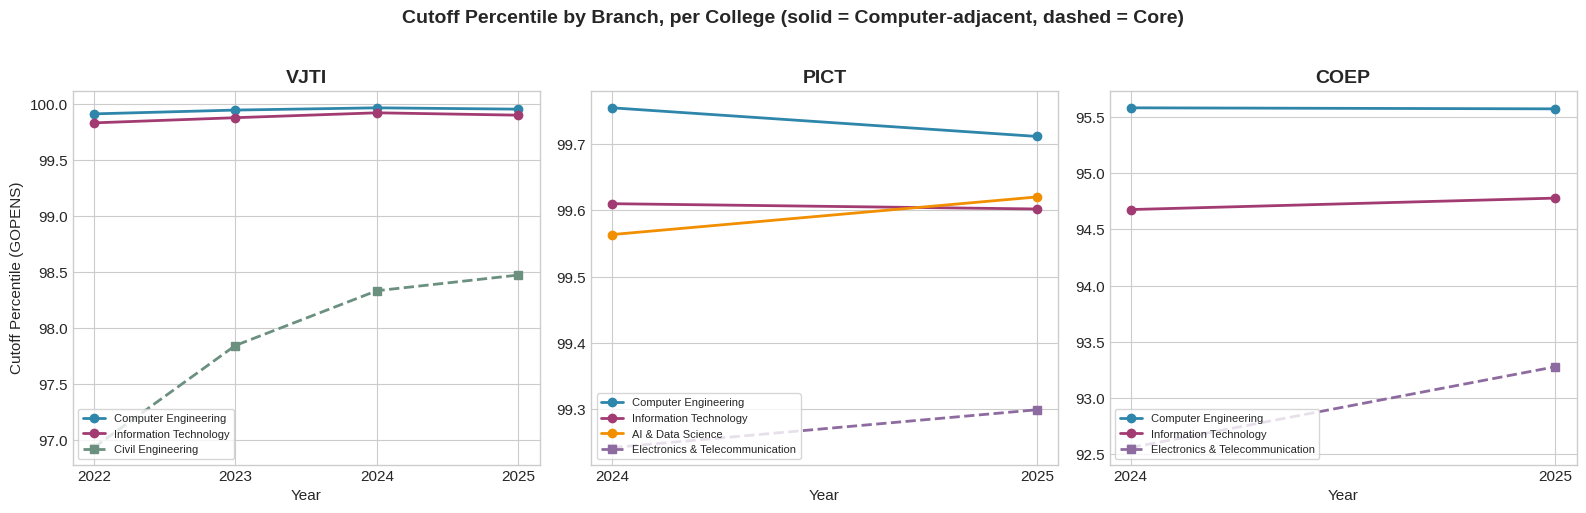


Computer-vs-Core gap, same college / same year:
 year college  computer_avg  core_avg  gap
 2022    VJTI         99.87     96.93 2.94
 2023    VJTI         99.91     97.84 2.07
 2024    COEP         95.13     92.56 2.57
 2024    PICT         99.64     99.24 0.40
 2024    VJTI         99.94     98.33 1.61
 2025    COEP         95.17     93.28 1.90
 2025    PICT         99.64     99.30 0.35
 2025    VJTI         99.93     98.47 1.45


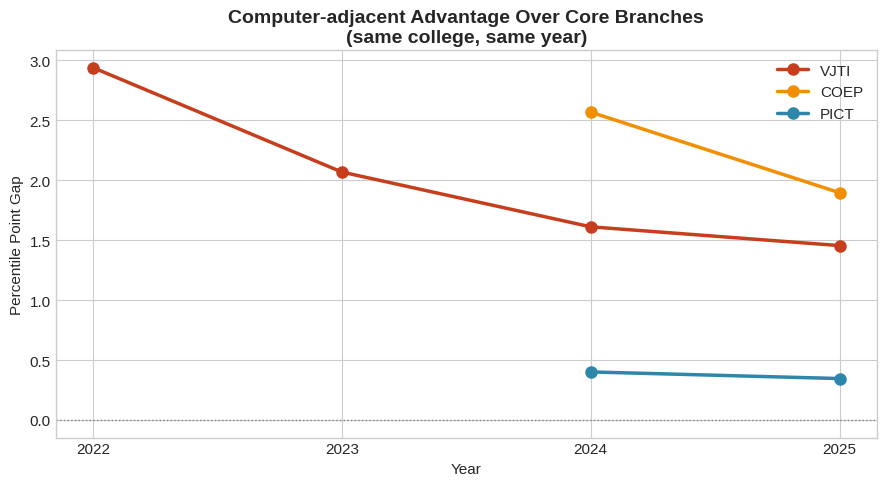

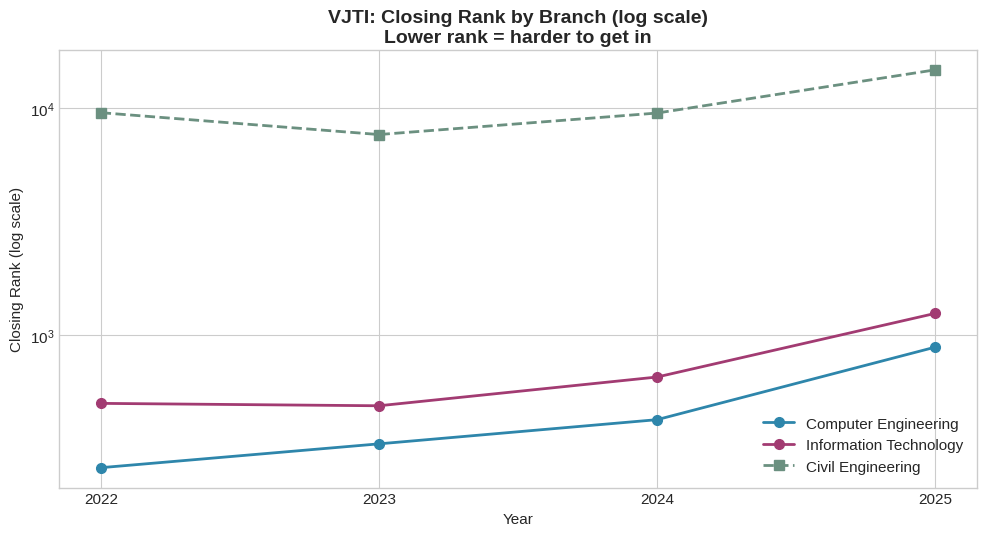


KEY FINDINGS
1. Computer-adjacent branches average 98.76 percentile vs 96.99 for core branches — a 1.77 point gap.
2. The gap holds at EVERY college in EVERY year measured — it is not
   driven by one institution or one admission cycle.
3. VJTI Civil rose from 96.93 to 98.47 percentile (2022-2025), so core branches
   are also getting harder — but Computer branches stay ~1.5 points ahead.
4. COEP shows LOWER percentiles (~95) than VJTI/PICT (~99.7) despite its
   reputation — larger intake capacity means the closing rank reaches
   deeper into the applicant pool. Percentile alone can mislead.

LIMITATIONS (state these openly):
- CAP Round 1 only; later rounds shift as seats fill.
- GOPENS category only; reserved-category cutoffs differ substantially.
- COEP absent from 2022-23 data (autonomy transition period).
- 3 colleges is a sample, not the full state picture.


In [1]:
"""
MHT-CET Engineering Cutoff Analysis (2022-2025)
Why are Computer branches booming?

Data source: DTE Maharashtra CET Cell — official CAP Round 1 cutoff PDFs
Extracted via: Python + pdfplumber + regex parsing of 1300-1500 page documents
Category: GOPENS (General, Open, State-level)

Paste this entire block into one Google Colab cell and run.
"""

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from io import StringIO

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

# ---------------- EMBEDDED DATA (no upload needed) ----------------

CUTOFF_CSV = """year,college,branch,category,rank,percentile,branch_category
2022,VJTI,Computer Engineering,GOPENS,259,99.9099739,Computer-adjacent
2022,VJTI,Information Technology,GOPENS,498,99.8297168,Computer-adjacent
2022,VJTI,Civil Engineering,GOPENS,9559,96.9302413,Core/Traditional
2023,VJTI,Computer Engineering,GOPENS,330,99.9440737,Computer-adjacent
2023,VJTI,Information Technology,GOPENS,486,99.8759212,Computer-adjacent
2023,VJTI,Civil Engineering,GOPENS,7653,97.8417807,Core/Traditional
2024,COEP,Computer Engineering,GOPENS,21989,95.5794695,Computer-adjacent
2024,COEP,Information Technology,GOPENS,26636,94.675361,Computer-adjacent
2024,COEP,Electronics & Telecommunication,GOPENS,40617,92.5598125,Core/Traditional
2024,VJTI,Computer Engineering,GOPENS,422,99.9641545,Computer-adjacent
2024,VJTI,Information Technology,GOPENS,651,99.9197093,Computer-adjacent
2024,VJTI,Civil Engineering,GOPENS,9523,98.3309085,Core/Traditional
2024,PICT,Computer Engineering,GOPENS,4873,99.7548103,Computer-adjacent
2024,PICT,Information Technology,GOPENS,5275,99.6101801,Computer-adjacent
2024,PICT,AI & Data Science,GOPENS,2282,99.5636454,Computer-adjacent
2024,PICT,Electronics & Telecommunication,GOPENS,10861,99.2422034,Core/Traditional
2025,COEP,Computer Engineering,GOPENS,29816,95.5703402,Computer-adjacent
2025,COEP,Information Technology,GOPENS,34972,94.7771148,Computer-adjacent
2025,COEP,Electronics & Telecommunication,GOPENS,44064,93.2783433,Core/Traditional
2025,VJTI,Computer Engineering,GOPENS,882,99.9522882,Computer-adjacent
2025,VJTI,Information Technology,GOPENS,1243,99.8985029,Computer-adjacent
2025,VJTI,Civil Engineering,GOPENS,14775,98.4709161,Core/Traditional
2025,PICT,Computer Engineering,GOPENS,2090,99.7116474,Computer-adjacent
2025,PICT,Information Technology,GOPENS,2776,99.6021953,Computer-adjacent
2025,PICT,AI & Data Science,GOPENS,2856,99.6203413,Computer-adjacent
2025,PICT,Electronics & Telecommunication,GOPENS,5286,99.2992853,Core/Traditional
"""

df = pd.read_csv(StringIO(CUTOFF_CSV))

BRANCH_COLORS = {
    "Computer Engineering": "#2E86AB",
    "Information Technology": "#A23B72",
    "AI & Data Science": "#F18F01",
    "Civil Engineering": "#6B9080",
    "Electronics & Telecommunication": "#8D6A9F",
}
COLLEGE_COLORS = {"VJTI": "#C73E1D", "PICT": "#2E86AB", "COEP": "#F18F01"}

print("Dataset loaded")
print(f"  {df.shape[0]} rows | {df['college'].nunique()} colleges | "
      f"{df['branch'].nunique()} branches | years {df['year'].min()}-{df['year'].max()}")
print()
print(df.groupby("branch_category")["percentile"].agg(["count", "mean", "min", "max"]).round(2))

# ============================================================
# CHART 1 — The core question: Computer vs Core branches
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5.5))
cat_means = df.groupby("branch_category")["percentile"].mean().sort_values(ascending=False)
bars = ax.bar(cat_means.index, cat_means.values, color=["#2E86AB", "#6B9080"], width=0.5)
ax.set_title("Average Cutoff Percentile: Computer vs Core Branches\n(CAP Round 1, GOPENS, 2022-2025)")
ax.set_ylabel("Average Cutoff Percentile")
ax.set_ylim(90, 100)
ax.bar_label(bars, fmt="%.2f", padding=4, fontsize=11, fontweight="bold")
gap = cat_means.iloc[0] - cat_means.iloc[1]
ax.text(0.5, 0.92, f"Gap: {gap:.2f} percentile points",
        transform=ax.transAxes, ha="center", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#FFF3CD", edgecolor="#F18F01"))
plt.tight_layout()
plt.show()

# ============================================================
# CHART 2 — Branch trends within each college (the main visual)
# ============================================================

colleges = ["VJTI", "PICT", "COEP"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, college in zip(axes, colleges):
    sub = df[df["college"] == college]
    for branch in sub["branch"].unique():
        bsub = sub[sub["branch"] == branch].sort_values("year")
        style = "-o" if bsub["branch_category"].iloc[0] == "Computer-adjacent" else "--s"
        ax.plot(bsub["year"], bsub["percentile"], style, linewidth=2, markersize=6,
                label=branch, color=BRANCH_COLORS.get(branch))
    ax.set_title(f"{college}")
    ax.set_xlabel("Year")
    ax.set_xticks(sorted(sub["year"].unique()))
    ax.legend(fontsize=8, loc="lower left", frameon=True)

axes[0].set_ylabel("Cutoff Percentile (GOPENS)")
fig.suptitle("Cutoff Percentile by Branch, per College (solid = Computer-adjacent, dashed = Core)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# CHART 3 — The gap within each college (apples-to-apples)
# ============================================================

gap_rows = []
for (year, college), grp in df.groupby(["year", "college"]):
    comp = grp[grp["branch_category"] == "Computer-adjacent"]["percentile"].mean()
    core = grp[grp["branch_category"] == "Core/Traditional"]["percentile"].mean()
    if not np.isnan(comp) and not np.isnan(core):
        gap_rows.append({"year": year, "college": college,
                          "computer_avg": comp, "core_avg": core, "gap": comp - core})
gap_df = pd.DataFrame(gap_rows)

print("\nComputer-vs-Core gap, same college / same year:")
print(gap_df.round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
for college in gap_df["college"].unique():
    sub = gap_df[gap_df["college"] == college].sort_values("year")
    ax.plot(sub["year"], sub["gap"], "-o", linewidth=2.5, markersize=8,
            label=college, color=COLLEGE_COLORS.get(college))
ax.axhline(0, color="gray", linewidth=1, linestyle=":")
ax.set_title("Computer-adjacent Advantage Over Core Branches\n(same college, same year)")
ax.set_xlabel("Year")
ax.set_ylabel("Percentile Point Gap")
ax.set_xticks(sorted(gap_df["year"].unique()))
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

# ============================================================
# CHART 4 — Rank tells the story percentile hides
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5.5))
vjti = df[df["college"] == "VJTI"]
for branch in vjti["branch"].unique():
    bsub = vjti[vjti["branch"] == branch].sort_values("year")
    style = "-o" if bsub["branch_category"].iloc[0] == "Computer-adjacent" else "--s"
    ax.plot(bsub["year"], bsub["rank"], style, linewidth=2, markersize=7,
            label=branch, color=BRANCH_COLORS.get(branch))
ax.set_yscale("log")
ax.set_title("VJTI: Closing Rank by Branch (log scale)\nLower rank = harder to get in")
ax.set_xlabel("Year")
ax.set_ylabel("Closing Rank (log scale)")
ax.set_xticks(sorted(vjti["year"].unique()))
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

# ============================================================
# KEY FINDINGS
# ============================================================

comp_avg = df[df["branch_category"] == "Computer-adjacent"]["percentile"].mean()
core_avg = df[df["branch_category"] == "Core/Traditional"]["percentile"].mean()
vjti_civil = df[(df.college == "VJTI") & (df.branch == "Civil Engineering")].sort_values("year")

print("\n" + "=" * 60)
print("KEY FINDINGS")
print("=" * 60)
print(f"1. Computer-adjacent branches average {comp_avg:.2f} percentile vs "
      f"{core_avg:.2f} for core branches — a {comp_avg - core_avg:.2f} point gap.")
print(f"2. The gap holds at EVERY college in EVERY year measured — it is not")
print(f"   driven by one institution or one admission cycle.")
print(f"3. VJTI Civil rose from {vjti_civil.percentile.iloc[0]:.2f} to "
      f"{vjti_civil.percentile.iloc[-1]:.2f} percentile (2022-2025), so core branches")
print(f"   are also getting harder — but Computer branches stay ~1.5 points ahead.")
print(f"4. COEP shows LOWER percentiles (~95) than VJTI/PICT (~99.7) despite its")
print(f"   reputation — larger intake capacity means the closing rank reaches")
print(f"   deeper into the applicant pool. Percentile alone can mislead.")
print()
print("LIMITATIONS (state these openly):")
print("- CAP Round 1 only; later rounds shift as seats fill.")
print("- GOPENS category only; reserved-category cutoffs differ substantially.")
print("- COEP absent from 2022-23 data (autonomy transition period).")
print("- 3 colleges is a sample, not the full state picture.")